In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet
from datetime import timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import numpy as np

In [28]:
overall_data = pd.read_excel(
    r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL data\overall time series.xlsx',
    parse_dates=['month'],
    date_format={
        'month':'%Y-%m'
    }
)

In [29]:
overall_data['month']

0     2001-11-01
1     2001-12-01
2     2002-01-01
3     2002-02-01
4     2002-03-01
         ...    
279   2025-02-01
280   2025-03-01
281   2025-04-01
282   2025-05-01
283   2025-06-01
Name: month, Length: 284, dtype: datetime64[ns]

In [32]:
overall_data['budget'] = overall_data['hr'] * 15_000 + overall_data['operations'] * 25_000 + overall_data['finance_and_accounts'] * 15_000 + overall_data['administration'] * 30_000 + overall_data['business'] * 27_000 + overall_data['management'] * 28_000 + overall_data['other_department']*15_000

In [18]:
overall_data

,month,headcount,comp_id,male_count,female_count,other_gender,hr,operations,finance_and_accounts,administration,...,christian,new_joins,resigned_employees,growth_rate,average_tenure_years,avg_ot_hours_per_emp,planned_leave_days,unplanned_leave_days,absenteeism_rate,budget
0,2001-11,1,OSCGPL,1,0,0,0,0,1,0,...,0,0,0,0,0.08,0.00,0.0,0.0,0.00,15000
1,2001-12,1,OSCGPL,1,0,0,0,0,1,0,...,0,0,0,0,0.17,0.00,0.0,0.0,0.00,15000
2,2002-01,1,OSCGPL,1,0,0,0,0,1,0,...,0,0,0,0,0.25,0.00,0.0,0.0,0.00,15000
3,2002-02,1,OSCGPL,1,0,0,0,0,1,0,...,0,0,0,0,0.33,0.00,0.0,0.0,0.00,15000
4,2002-03,1,OSCGPL,1,0,0,0,0,1,0,...,0,0,0,0,0.42,0.00,0.0,0.0,0.00,15000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,2025-02,16953,OSCGPL,13351,3602,0,88,16666,35,9,...,0,1077,1128,0,2.19,0.00,0.0,0.0,0.00,421247000
280,2025-03,16860,OSCGPL,13236,3624,0,86,16578,35,9,...,0,1076,1129,0,2.24,0.00,15.5,187.0,0.05,418948000
281,2025-04,16813,OSCGPL,13138,3675,0,83,16537,36,9,...,0,1112,1528,0,2.26,0.00,213.0,17.5,0.06,417833000
282,2025-05,16447,OSCGPL,12811,3636,0,82,16168,37,9,...,0,1230,388,0,2.29,6.02,939.5,9.5,0.26,408653000


### old approach

In [8]:
configs = [
    {"seasonality_mode": "additive", "changepoint_prior_scale": 0.05},
    {"seasonality_mode": "additive", "changepoint_prior_scale": 0.5},
    {"seasonality_mode": "multiplicative", "changepoint_prior_scale": 0.05},
    {"seasonality_mode": "multiplicative", "changepoint_prior_scale": 0.5}
]

In [9]:
df_prophet = overall_data.reset_index()[["month", "headcount"]].rename(columns={"month": "ds", "headcount": "y"})
forecast_horizon = 3
initial_train_size = int(len(df_prophet) * 0.8)

In [10]:
results = []

for config in configs:
    predictions = []
    actuals = []
    forecast_dates = []

    for start in range(initial_train_size, len(df_prophet) - forecast_horizon + 1):
        train = df_prophet.iloc[:start]
        test = df_prophet.iloc[start:start + forecast_horizon]

        # Prophet model with current config
        model = Prophet(
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"]
        )
        model.fit(train)

        future = model.make_future_dataframe(periods=forecast_horizon, freq='M')
        forecast = model.predict(future)

        forecast_values = forecast[["ds", "yhat"]].iloc[-forecast_horizon:]
        predictions.extend(forecast_values["yhat"].values)
        actuals.extend(test["y"].values)
        forecast_dates.extend(test["ds"].values)

    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    results.append((config, mae, mse, predictions, actuals))

14:26:35 - cmdstanpy - INFO - Chain [1] start processing
14:26:39 - cmdstanpy - INFO - Chain [1] done processing
d:\surya.iyer\My Documents\projects\predictive analysis\.predictive\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
14:26:39 - cmdstanpy - INFO - Chain [1] start processing
14:26:39 - cmdstanpy - INFO - Chain [1] done processing
d:\surya.iyer\My Documents\projects\predictive analysis\.predictive\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
14:26:39 - cmdstanpy - INFO - Chain [1] start processing
14:26:39 - cmdstanpy - INFO - Chain [1] done processing
d:\surya.iyer\My Documents\projects\predictive analysis\.predictive\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future versio

In [82]:
results = sorted(results, key=lambda x: x[1])
best_config, best_mae, best_mse, best_preds, best_actuals = results[0]

print(f"\nBest Config: {best_config}")
print(f"MAE: {best_mae:.2f}, MSE: {best_mse:.2f}")


Best Config: {'seasonality_mode': 'additive', 'changepoint_prior_scale': 0.5}
MAE: 12.28, MSE: 531.57


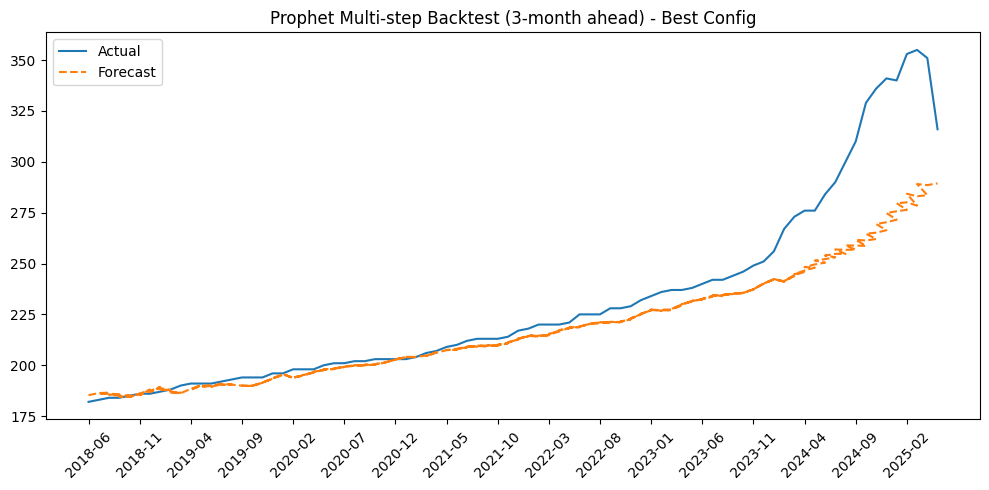

In [84]:
# test_dates = df_prophet["ds"].iloc[-len(best_actuals):]
plt.figure(figsize=(10, 5))
plt.plot(forecast_dates, best_actuals, label="Actual")
plt.plot(forecast_dates, best_preds, label="Forecast", linestyle="--")
plt.title(f"Prophet Multi-step Backtest ({forecast_horizon}-month ahead) - Best Config")
plt.legend()
plt.xticks(forecast_dates[::15])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
final_model = Prophet(
    seasonality_mode=best_config["seasonality_mode"],
    changepoint_prior_scale=best_config["changepoint_prior_scale"]
)
final_model.fit(df_prophet)

12:50:23 - cmdstanpy - INFO - Chain [1] start processing
12:50:23 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
future = final_model.make_future_dataframe(periods=forecast_horizon + 10, freq='ME')
forecast = final_model.predict(future)

forecast.tail(forecast_horizon + 10)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
416,2025-05-31,298.564141,286.249502,310.072121,298.564141,298.564141,-0.425929,-0.425929,-0.425929,-0.425929,-0.425929,-0.425929,0.0,0.0,0.0,298.138212
417,2025-06-30,300.119608,288.072591,311.487606,300.119608,300.119608,0.011138,0.011138,0.011138,0.011138,0.011138,0.011138,0.0,0.0,0.0,300.130746
418,2025-07-31,301.726924,288.884211,313.850240,301.726924,301.726924,-0.365668,-0.365668,-0.365668,-0.365668,-0.365668,-0.365668,0.0,0.0,0.0,301.361256
419,2025-08-31,303.334240,290.935992,315.555143,303.282125,303.334240,0.013902,0.013902,0.013902,0.013902,0.013902,0.013902,0.0,0.0,0.0,303.348142
420,2025-09-30,304.889707,291.411401,315.650579,304.683467,304.911036,-0.853742,-0.853742,-0.853742,-0.853742,-0.853742,-0.853742,0.0,0.0,0.0,304.035965
421,2025-10-31,306.497023,293.718039,318.961724,306.108006,306.698092,-0.039236,-0.039236,-0.039236,-0.039236,-0.039236,-0.039236,0.0,0.0,0.0,306.457787
422,2025-11-30,308.052490,295.939058,320.312719,307.416335,308.425897,0.594709,0.594709,0.594709,0.594709,0.594709,0.594709,0.0,0.0,0.0,308.647199
423,2025-12-31,309.659806,297.189593,322.286969,308.780466,310.207029,0.855108,0.855108,0.855108,0.855108,0.855108,0.855108,0.0,0.0,0.0,310.514914
424,2026-01-31,311.267122,298.355410,323.055309,310.144719,311.987501,-0.649775,-0.649775,-0.649775,-0.649775,-0.649775,-0.649775,0.0,0.0,0.0,310.617347
425,2026-02-28,312.718892,303.559320,329.131454,311.316347,313.764399,3.171520,3.171520,3.171520,3.171520,3.171520,3.171520,0.0,0.0,0.0,315.890411


In [87]:
forecast.rename(columns={'ds':'Month'}, inplace=True)

In [88]:
forecast['Predicted Headcount'] = forecast['trend'].round()

In [89]:
forecast.tail(forecast_horizon+10).to_excel('overall_headcount_prediction.xlsx',index=False)

### New approach

In [36]:
df_prophet = overall_data[['month', 'headcount']].rename(columns={'month': 'ds', 'headcount': 'y'})

In [37]:
# Add exogenous factors as additional regressors
exogenous_factors = ['new_joins', 'resigned_employees','growth_rate', 'average_tenure_years', 'avg_ot_hours_per_emp', 
                     'planned_leave_days', 'unplanned_leave_days', 'absenteeism_rate','budget']
for factor in exogenous_factors:
    df_prophet[factor] = overall_data[factor]

In [38]:
future_exogenous = pd.DataFrame({'ds': pd.date_range(start=df_prophet['ds'].max() + timedelta(days=1), periods=12, freq='MS')})

In [39]:
# Forecast each exogenous factor separately
exogenous_forecasts = {}

for factor in exogenous_factors:
    temp_df = overall_data[['month', factor, 'headcount']].rename(columns={'month': 'ds', factor: 'y'})
    factor_model = Prophet()
    factor_model.fit(temp_df)

    forecast = factor_model.predict(future_exogenous)
    
    if factor in ['new_joins', 'absenteeism_rate', 'resigned_employees', 'planned_leave_days','unplanned_leave_days','avg_ot_hrs_per_emp','growth_rate']:
        forecast['yhat'] = forecast['yhat'].clip(lower=0)
    
    exogenous_forecasts[factor] = forecast[['ds', 'yhat']].rename(columns={'yhat': factor})
    
    if factor in ['new_joins','resigned_employees','budget','growth_rate']:
        exogenous_forecasts[factor] = exogenous_forecasts[factor].round()
    else:
        exogenous_forecasts[factor] = exogenous_forecasts[factor].round(2)
    
    
    future_exogenous = future_exogenous.merge(exogenous_forecasts[factor], on='ds', how='left')

16:32:18 - cmdstanpy - INFO - Chain [1] start processing
16:32:18 - cmdstanpy - INFO - Chain [1] done processing
16:32:18 - cmdstanpy - INFO - Chain [1] start processing
16:32:18 - cmdstanpy - INFO - Chain [1] done processing
16:32:18 - cmdstanpy - INFO - Chain [1] start processing
16:32:19 - cmdstanpy - INFO - Chain [1] done processing
16:32:19 - cmdstanpy - INFO - Chain [1] start processing
16:32:19 - cmdstanpy - INFO - Chain [1] done processing
16:32:19 - cmdstanpy - INFO - Chain [1] start processing
16:32:19 - cmdstanpy - INFO - Chain [1] done processing
16:32:19 - cmdstanpy - INFO - Chain [1] start processing
16:32:19 - cmdstanpy - INFO - Chain [1] done processing
16:32:19 - cmdstanpy - INFO - Chain [1] start processing
16:32:19 - cmdstanpy - INFO - Chain [1] done processing
16:32:20 - cmdstanpy - INFO - Chain [1] start processing
16:32:20 - cmdstanpy - INFO - Chain [1] done processing
16:32:20 - cmdstanpy - INFO - Chain [1] start processing
16:32:20 - cmdstanpy - INFO - Chain [1]

In [40]:
future_exogenous

,ds,new_joins,resigned_employees,growth_rate,average_tenure_years,avg_ot_hours_per_emp,planned_leave_days,unplanned_leave_days,absenteeism_rate,budget
0,2025-07-01,1187.0,987.0,0.0,2.29,0.15,33.25,5.67,0.01,388818916.0
1,2025-08-01,1115.0,939.0,0.0,2.29,0.16,33.85,5.77,0.01,393312379.0
2,2025-09-01,1112.0,962.0,0.0,2.30,0.16,34.40,5.86,0.01,397184227.0
3,2025-10-01,1131.0,1191.0,2.0,2.30,0.16,34.95,5.92,0.01,402182931.0
4,2025-11-01,1158.0,1045.0,0.0,2.29,0.17,35.66,6.00,0.01,398480572.0
5,2025-12-01,1173.0,1085.0,0.0,2.30,0.17,36.00,5.99,0.01,399757221.0
6,2026-01-01,1154.0,1006.0,4.0,2.30,0.17,36.28,5.99,0.01,399520628.0
7,2026-02-01,1123.0,1003.0,0.0,2.26,0.17,36.40,5.94,0.01,400713865.0
8,2026-03-01,1144.0,1126.0,0.0,2.28,0.18,38.03,13.56,0.01,403510980.0
9,2026-04-01,1191.0,1098.0,0.0,2.29,0.18,46.62,7.05,0.01,405599418.0


In [41]:
headcount_model = Prophet(seasonality_mode='additive')

for factor in exogenous_factors:
    headcount_model.add_regressor(factor)

headcount_model.fit(df_prophet)

16:32:28 - cmdstanpy - INFO - Chain [1] start processing
16:32:28 - cmdstanpy - INFO - Chain [1] done processing


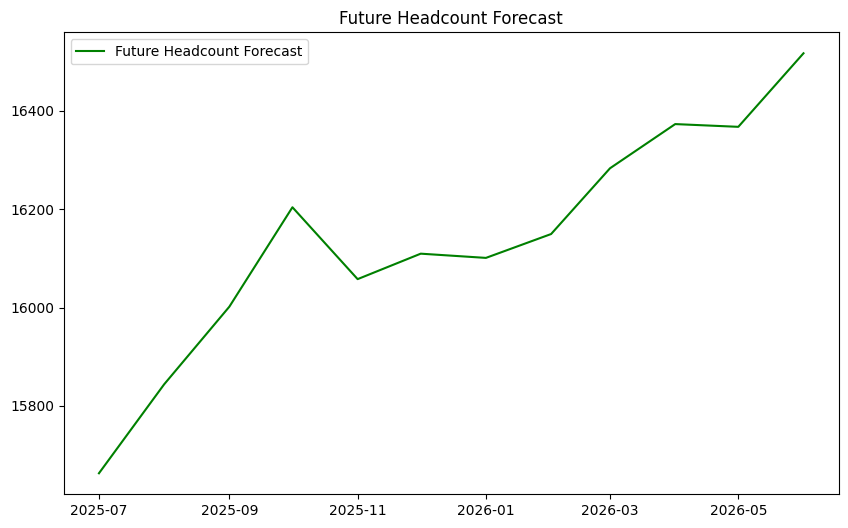

In [43]:
forecast_headcount = headcount_model.predict(future_exogenous)

# Plot the future forecast of headcount
plt.figure(figsize=(10, 6))
plt.plot(forecast_headcount['ds'], forecast_headcount['yhat'], label='Future Headcount Forecast', color='green')
plt.title('Future Headcount Forecast')
plt.legend()
plt.show()

In [95]:
forecast_headcount.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'absenteeism_rate', 'absenteeism_rate_lower', 'absenteeism_rate_upper',
       'average_tenure_years', 'average_tenure_years_lower',
       'average_tenure_years_upper', 'avg_ot_hours_per_emp',
       'avg_ot_hours_per_emp_lower', 'avg_ot_hours_per_emp_upper', 'budget',
       'budget_lower', 'budget_upper', 'extra_regressors_multiplicative',
       'extra_regressors_multiplicative_lower',
       'extra_regressors_multiplicative_upper', 'growth_rate',
       'growth_rate_lower', 'growth_rate_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'new_joins',
       'new_joins_lower', 'new_joins_upper', 'planned_leave_days',
       'planned_leave_days_lower', 'planned_leave_days_upper',
       'resigned_employees', 'resigned_employees_lower',
       'resigned_employees_upper', 'unplanned_leave_days',
       'unplanned_leave_days_lower', 'unplanned_leave_days

In [44]:
overall_prediction = pd.concat(
    [
        future_exogenous[['ds','absenteeism_rate','average_tenure_years','avg_ot_hours_per_emp','budget','new_joins','resigned_employees','unplanned_leave_days']],
        forecast_headcount['yhat']
    ],
    axis=1
).rename(columns={'yhat':'Predicted Headcount','ds':'Month'})

In [45]:
overall_prediction['Predicted Headcount'] = overall_prediction['Predicted Headcount'].round()

In [46]:
overall_prediction

,Month,absenteeism_rate,average_tenure_years,avg_ot_hours_per_emp,budget,new_joins,resigned_employees,unplanned_leave_days,Predicted Headcount
0,2025-07-01,0.01,2.29,0.15,388818916.0,1187.0,987.0,5.67,15663.0
1,2025-08-01,0.01,2.29,0.16,393312379.0,1115.0,939.0,5.77,15844.0
2,2025-09-01,0.01,2.30,0.16,397184227.0,1112.0,962.0,5.86,16002.0
3,2025-10-01,0.01,2.30,0.16,402182931.0,1131.0,1191.0,5.92,16204.0
4,2025-11-01,0.01,2.29,0.17,398480572.0,1158.0,1045.0,6.00,16058.0
5,2025-12-01,0.01,2.30,0.17,399757221.0,1173.0,1085.0,5.99,16110.0
6,2026-01-01,0.01,2.30,0.17,399520628.0,1154.0,1006.0,5.99,16101.0
7,2026-02-01,0.01,2.26,0.17,400713865.0,1123.0,1003.0,5.94,16150.0
8,2026-03-01,0.01,2.28,0.18,403510980.0,1144.0,1126.0,13.56,16283.0
9,2026-04-01,0.01,2.29,0.18,405599418.0,1191.0,1098.0,7.05,16373.0


In [47]:
overall_prediction.to_excel(r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL model predictions\overall_headcount_prediction.xlsx',index=False)

### XGBoost and regression instead of forecasting

In [7]:
overall_data_shifted = overall_data.copy()
overall_data_shifted['headcount_next_month'] = overall_data_shifted['headcount'].shift(-1)
overall_data_shifted = overall_data_shifted.dropna(subset=['headcount_next_month'])

In [9]:
overall_data_shifted

,month,headcount,comp_id,male_count,female_count,other_gender,hr,it,payroll,software,...,new_joins,resigned_employees,growth_rate,average_tenure_years,avg_ot_hours_per_emp,planned_leave_days,unplanned_leave_days,absenteeism_rate,budget,headcount_next_month
0,1990-10-01,1,1,0,1,0,0,0,0,1,...,1,0,100.00,0.08,0.00,0.0,0.0,0.00,30000,1.0
1,1990-11-01,1,1,0,1,0,0,0,0,1,...,0,0,0.00,0.16,0.00,0.0,0.0,0.00,30000,1.0
2,1990-12-01,1,1,0,1,0,0,0,0,1,...,0,0,0.00,0.24,0.00,0.0,0.0,0.00,30000,1.0
3,1991-01-01,1,1,0,1,0,0,0,0,1,...,0,0,0.00,0.33,0.00,0.0,0.0,0.00,30000,2.0
4,1991-02-01,2,1,0,2,0,0,0,0,2,...,1,0,50.00,0.24,0.00,0.0,0.0,0.00,60000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,2024-12-01,341,1,306,29,6,146,0,0,80,...,6,3,1.76,10.41,0.00,1.0,2.0,0.04,6315000,340.0
411,2025-01-01,340,1,303,31,6,145,0,0,81,...,3,0,0.88,10.52,0.14,4.0,2.0,0.08,6315000,353.0
412,2025-02-01,353,1,309,35,9,150,0,0,83,...,13,0,3.68,10.21,1.79,3.5,2.0,0.07,6540000,355.0
413,2025-03-01,355,1,309,37,9,150,0,0,83,...,2,4,0.56,10.24,2.03,31.5,31.0,0.80,6570000,351.0


In [36]:
exogenous_factors = ['new_joins', 'resigned_employees', 'growth_rate', 'average_tenure_years', 
                     'avg_ot_hours_per_emp', 'unplanned_leave_days', 
                     'absenteeism_rate', 'budget']

# Prepare the features (X) and target (y)
X = overall_data_shifted[exogenous_factors]
y = overall_data_shifted['headcount_next_month']
train_size = int(0.8 * len(X))
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values if any
            ('scaler', StandardScaler())  # Standardize numerical features
        ]), exogenous_factors)
    ])

In [38]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', n_estimators=100, random_state=42)

In [39]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Apply preprocessing (scaling)
    ('model', xgb_model)  # Apply XGBoost model
])

In [40]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['new_joins',
                                                   'resigned_employees',
                                                   'growth_rate',
                                                   'average_tenure_years',
                                                   'avg_ot_hours_per_emp',
                                                   'unplanned_leave_days',
                                                   'absenteeism_rate',
                                                   'budget'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, call...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [41]:
y_pred = pipeline.predict(X_test)

In [42]:
# Print the results
print(f"Predicted headcount for the next month: {y_pred}")
print(f"Actual headcount for the next month: {y_test.values}")

# Evaluate the model
print(f"R^2 score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

Predicted headcount for the next month: [182.00288 179.48987 179.46335 182.12804 179.9606  179.9606  182.5823
 179.9606  179.9606  181.93028 179.9606  182.5823  182.5823  179.9606
 179.9606  179.9606  182.5823  182.5823  181.91997 182.5823  181.87503
 182.5823  182.5823  181.87503 179.9606  182.5823  179.9606  182.5823
 179.9606  182.5823  182.5823  182.5823  179.9606  181.87503 179.9606
 181.87503 179.9606  181.87503 179.9606  182.5823  182.5823  179.9606
 182.07985 179.9606  181.87503 182.5823  182.5823  179.9606  182.05109
 182.5823  182.5823  182.06856 182.5823  179.9606  182.06856 181.962
 181.962   179.9606  182.5823  179.9606  181.96768 181.96768 182.5823
 181.96768 181.96768 181.93028 181.96768 182.05109 182.12996 182.07639
 181.93028 182.5823  182.10822 182.07904 181.97194 181.93707 175.15358
 170.04189 168.64345 169.79106 167.99524 167.74664 169.1384 ]
Actual headcount for the next month: [183. 184. 184. 185. 186. 186. 187. 188. 190. 191. 191. 191. 192. 193.
 194. 194. 194. 1